In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/TestSimiliarity')
os.getcwd()
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [3]:
STIG = "https://complianceascode.github.io/content-pages/guides/ssg-ol8-guide-stig.html#"
CIS = "/content/drive/MyDrive/TestSimiliarity/data/CIS_Oracle_Linux_8_Benchmark_v3.0.0.pdf"

FIRST_PAGE = 20
LAST_PAGE = 887
FIRST_PAGE_INDICATOR = "Profile Applicability"
LAST_PAGE_INDICATOR = "CIS Controls"

In [12]:
!pip install pypdf
from pypdf import PdfReader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.2/304.2 kB 5.6 MB/s eta 0:00:00


In [4]:
import spacy
from spacy.tokens import Doc, Token, Span
import csv
import re
from typing import Tuple, List
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import semantic_search, cos_sim, normalize_embeddings
from transformers import LongformerTokenizer, LongformerModel, BigBirdTokenizer, BigBirdModel
import torch
from torch import Tensor
import numpy as np
from numpy import array
import requests
from bs4 import BeautifulSoup, ResultSet, Tag
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
reader = PdfReader(CIS)

In [ ]:
reader.pages[30].extract_text()

'Page 30 \n1.1.1.3 Ensure hfs kernel module is not available (Automated) \nProfile Applicability: \n•  Level 1 - Server \n•  Level 1 - Workstation \nDescription: \nThe hfs filesystem type is a hierarchical filesystem that allows you to mount Mac OS \nfilesystems. \nRationale: \nRemoving support for unneeded filesystem types reduces the local attack surface of the \nsystem. If this filesystem type is not needed, disable it. \nAudit: \nRun the following script to verify the hfs module is disabled: \n-IF- the module is available in the running kernel: \n• An entry including /bin/true or /bin/false exists in a file within the \n/etc/modprobe.d/ directory \n• The module is deny listed in a file within the /etc/modprobe.d/ directory \n• The module is not loaded in the kernel \n-IF- available in ANY installed kernel: \n• The module is deny listed in a file within the /etc/modprobe.d/ directory \n-IF- the kernel module is not available on the system, or pre-compiled into the kernel: \n• No add

# Process CIS

## 1st Approach
### Use all the text

In [8]:
processed_cis_path = "processed_data/processed_cis.csv"

In [28]:
nlp = spacy.load("en_core_web_sm")

In [46]:
def clean_text(text: str) -> str:
    text = re.sub("\xa0", '', text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def remove_page_n_text(text: str) -> str:
    # Removes Page n text from page
    result = re.search(r".+\n", text)
    if result:
        return text[result.end():]
    else:
        return text

def extract_rule_title(text: str) -> str:
    result = re.search(r"^(.*?)(?=Profile Applicability)", text)
    if result:
        return text[result.start():result.end()].strip()
    else:
        return ""

def process_rules(reader: PdfReader) -> Tuple[List[str], List[str]]:
    """
    Extract all the text for each rule
    """
    rule = ""
    rule_lst = []
    rule_title_lst = []
    for i in tqdm(range(FIRST_PAGE, LAST_PAGE)):
        text = remove_page_n_text(reader.pages[i].extract_text())
        # If first page of rule found
        if re.search(FIRST_PAGE_INDICATOR, text) is not None:
            title = extract_rule_title(clean_text(text))
            rule_title_lst.append(title)
            if rule != "":
                rule_lst.append(rule)
            rule = text
        else:
            rule += " " + text
    # Account for last rule
    if rule != "":
        rule_lst.append(rule)
    assert len(rule_title_lst) == len(rule_lst)
    return rule_title_lst, rule_lst

In [47]:
extract_rule_title(clean_text(remove_page_n_text(reader.pages[878].extract_text())))

'6.2.10 Ensure local interactive user home directories are configured (Automated)'

In [20]:
remove_page_n_text(reader.pages[45].extract_text())

'1.1.1.6 Ensure squashfs kernel module is not available \n(Automated) \nProfile Applicability: \n•  Level 2 - Server \n•  Level 2 - Workstation \nDescription: \nThe squashfs filesystem type is a compressed read-only Linux filesystem embedded in \nsmall footprint systems. A squashfs image can be used without having to first \ndecompress the image. \nRationale: \nRemoving support for unneeded filesystem types reduces the local attack surface of the \nsystem. If this filesystem type is not needed, disable it. \nImpact: \nAs Snap packages utilizes squashfs as a compressed filesystem, disabling squashfs \nwill cause Snap packages to fail. \nSnap application packages of software are self-contained and work across a range of \nLinux distributions. This is unlike traditional Linux package management approaches, \nlike APT or RPM, which require specifically adapted packages per Linux distribution on \nan application update and delay therefore application deployment from developers to \ntheir so

In [ ]:
cis_titles, cis_rules = process_rules(reader)

100%|██████████| 867/867 [00:32<00:00, 27.07it/s]


In [ ]:
with open(processed_cis_path, "w") as file:
    writer = csv.writer(file)
    for item in zip(cis_titles, cis_rules):
        writer.writerow([item[0], item[1]])

In [ ]:
cis_rules[6]

'1.1.1.7 Ensure udf kernel module is not available (Automated) \nProfile Applicability: \n•  Level 2 - Server \n•  Level 2 - Workstation \nDescription: \nThe udf filesystem type is the universal disk format used to implement ISO/IEC 13346 \nand ECMA-167 specifications. This is an open vendor filesystem type for data storage \non a broad range of media. This filesystem type is necessary to support writing DVDs \nand newer optical disc formats. \nRationale: \nRemoving support for unneeded filesystem types reduces the local attack surface of the \nsystem. If this filesystem type is not needed, disable it. \nImpact: \nMicrosoft Azure requires the usage of udf. \nudf should not be disabled on systems run on Microsoft Azure. \nAudit: \nRun the following script to verify the udf module is disabled: \n-IF- the module is available in the running kernel: \n• An entry including /bin/true or /bin/false exists in a file within the \n/etc/modprobe.d/ directory \n• The module is deny listed in a file

## 2nd Approach
### Extract Description and Rationale only

In [22]:
cis_df = pd.read_csv("processed_data/processed_cis.csv", header = None)
cis_titles = cis_df[0].to_list()

In [11]:
cis_df.head()

,0,1
0,1.1.1.1 Ensure cramfs kernel module is not ava...,1.1.1.1 Ensure cramfs kernel module is not ava...
1,1.1.1.2 Ensure freevxfs kernel module is not a...,1.1.1.2 Ensure freevxfs kernel module is not a...
2,1.1.1.3 Ensure hfs kernel module is not availa...,1.1.1.3 Ensure hfs kernel module is not availa...
3,1.1.1.4 Ensure hfsplus kernel module is not av...,1.1.1.4 Ensure hfsplus kernel module is not av...
4,1.1.1.5 Ensure jffs2 kernel module is not avai...,1.1.1.5 Ensure jffs2 kernel module is not avai...


In [12]:
cis_df.loc[5, 1]

'1.1.1.6 Ensure squashfs kernel module is not available \n(Automated) \nProfile Applicability: \n•  Level 2 - Server \n•  Level 2 - Workstation \nDescription: \nThe squashfs filesystem type is a compressed read-only Linux filesystem embedded in \nsmall footprint systems. A squashfs image can be used without having to first \ndecompress the image. \nRationale: \nRemoving support for unneeded filesystem types reduces the local attack surface of the \nsystem. If this filesystem type is not needed, disable it. \nImpact: \nAs Snap packages utilizes squashfs as a compressed filesystem, disabling squashfs \nwill cause Snap packages to fail. \nSnap application packages of software are self-contained and work across a range of \nLinux distributions. This is unlike traditional Linux package management approaches, \nlike APT or RPM, which require specifically adapted packages per Linux distribution on \nan application update and delay therefore application deployment from developers to \ntheir so

In [25]:
def clean_text(text: str) -> str:
    text = re.sub("\xa0", '', text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def clean_spacy_doc(doc: Doc) -> str:
    lst = []
    for token in doc:
        if token.is_ascii and not token.is_space:
            lst.append(token)
    return ''.join([token.text_with_ws for token in lst])

def extract_text(text: str) -> str:
    title = re.findall(r".+(?=\s+Profile)", text)
    descript = re.findall(r"(?<=Description:).+(?=\s+Rationale)", text)
    impact = re.findall(r"(?<=Impact:).+(?=\s+Audit:)", text)
    result = title
    result.extend(descript)
    result.extend(impact)
    return ".".join(result)

In [32]:
a = cis_df.loc[:, 1].to_list()
extract_rule_title(clean_spacy_doc(nlp(a[285])))

''

In [14]:
cis_rules = cis_df.loc[:, 1].to_list()
cis_rules = nlp.pipe(cis_rules)
cis_rules = map(clean_spacy_doc, cis_rules)
cis_rules = list(map(extract_text, cis_rules))

In [15]:
cis_rules[5]

'1.1.1.6 Ensure squashfs kernel module is not available (Automated). The squashfs filesystem type is a compressed read-only Linux filesystem embedded in small footprint systems. A squashfs image can be used without having to first decompress the image.. As Snap packages utilizes squashfs as a compressed filesystem, disabling squashfs will cause Snap packages to fail. Snap application packages of software are self-contained and work across a range of Linux distributions. This is unlike traditional Linux package management approaches, like APT or RPM, which require specifically adapted packages per Linux distribution on an application update and delay therefore application deployment from developers to their software\'s end-user. Snaps themselves have no dependency on any external store ("App store"), can be obtained from any source and can be therefore used for upstream software deployment.'

In [21]:
with open("processed_data/processed_cis_2.csv", "w") as file:
    writer = csv.writer(file)
    for item in zip(cis_titles, cis_rules):
        writer.writerow([item[0], item[1]])

In [22]:
cis_rules[0]

'1.1.1.1 Ensure cramfs kernel module is not available (Automated). The cramfs filesystem type is a compressed read-only Linux filesystem embedded in small footprint systems. A cramfs image can be used without having to first decompress the image.'

# Process STIG

## 1st Approach

In [23]:
r = requests.get(STIG)

# check status code for response received
# success code - 200
print(r)

# Parsing the HTML
soup = BeautifulSoup(r.content, 'html.parser')
# print(soup.prettify())

<Response [200]>


In [24]:
# Get all rules
STIG_rules_regex = re.compile(r"^guide-tree-leaf-id.+")
STIG_rules_tables = soup.find_all(id=STIG_rules_regex)

In [68]:
# Remove unneccessary characters and multiple spaces
def clean_text(text: str) -> str:
    text = re.sub("\xa0", '', text)
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"\s+", " ", text)
    # doc = nlp(text)
    return text

# Extract title
def extract_title(text: str) -> str:
    search = re.findall("Rule\s(.+)\s\[ref\]", text)
    return search[0] if len(search) > 0 else ""

In [26]:
clean_text(STIG_rules_tables[0].get_text())

'Rule Install AIDE [ref]The aide package can be installed with the following command: $ sudo yum install aide Rationale:The AIDE package must be installed if it is to be available for integrity checking.Severity:mediumRule ID:xccdf_org.ssgproject.content_rule_package_aide_installedReferences:cis-csc1, 11, 12, 13, 14, 15, 16, 2, 3, 5, 7, 8, 9cjis5.10.1.3cobit5APO01.06, BAI01.06, BAI02.01, BAI03.05, BAI06.01, BAI10.01, BAI10.02, BAI10.03, BAI10.05, DSS01.03, DSS03.05, DSS04.07, DSS05.02, DSS05.03, DSS05.05, DSS05.07, DSS06.02, DSS06.06isa-62443-20094.3.4.3.2, 4.3.4.3.3, 4.3.4.4.4isa-62443-2013SR 3.1, SR 3.3, SR 3.4, SR 3.8, SR 4.1, SR 6.2, SR 7.6ism1034, 1288, 1341, 1417iso27001-2013A.11.2.4, A.12.1.2, A.12.2.1, A.12.4.1, A.12.5.1, A.12.6.2, A.14.1.2, A.14.1.3, A.14.2.2, A.14.2.3, A.14.2.4, A.14.2.7, A.15.2.1, A.8.2.3nistCM-6(a)nist-csfDE.CM-1, DE.CM-7, PR.DS-1, PR.DS-6, PR.DS-8, PR.IP-1, PR.IP-3pcidssReq-11.5os-srgSRG-OS-000445-GPOS-00199stigidOL08-00-010359anssiR76, R79pcidss411.5.2sti

In [ ]:
STIG_rules = [clean_text(i.get_text()) for i in STIG_rules_tables]
STIG_titles = [extract_title(i) for i in STIG_rules]
assert len(STIG_rules) == len(STIG_titles)

In [ ]:
with open("processed_data/processed_stig.csv", "w") as file:
    writer = csv.writer(file)
    for item in zip(STIG_titles, STIG_rules):
        writer.writerow([item[0], item[1]])

## 2nd Approach
### Extract Description and Rationale only

In [27]:
r = requests.get(STIG)

# check status code for response received
# success code - 200
print(r)

# Parsing the HTML
soup = BeautifulSoup(r.content, 'html.parser')
# print(soup.prettify())

<Response [200]>


In [63]:
# Remove unneccessary characters and multiple spaces
def clean_text(text: str) -> str:
    text = re.sub("\xa0", '', text)
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"\s+", " ", text)
    # doc = nlp(text)
    return text

def extract_info(ele: Tag) -> str:
    title = re.findall(r"Rule\s(.+)\s\[ref\]", clean_text(ele.get_text()))[0].strip()
    descrip = clean_text(ele.find_all(class_ = "description")[0].get_text().strip())
    rationale = clean_text(ele.find_all(class_ = "rationale")[0].get_text().strip())
    return ".".join([title, descrip, rationale])

In [54]:
STIG_rules_tables[0].get_text()

'Rule\xa0\xa0\n                                Install AIDE\n                                \xa0\xa0[ref]The aide package can be installed with the following command:\n\n$ sudo yum install aide\nRationale:The AIDE package must be installed if it is to be available for integrity checking.Severity:\xa0mediumRule ID:xccdf_org.ssgproject.content_rule_package_aide_installedReferences:cis-csc1, 11, 12, 13, 14, 15, 16, 2, 3, 5, 7, 8, 9cjis5.10.1.3cobit5APO01.06, BAI01.06, BAI02.01, BAI03.05, BAI06.01, BAI10.01, BAI10.02, BAI10.03, BAI10.05, DSS01.03, DSS03.05, DSS04.07, DSS05.02, DSS05.03, DSS05.05, DSS05.07, DSS06.02, DSS06.06isa-62443-20094.3.4.3.2, 4.3.4.3.3, 4.3.4.4.4isa-62443-2013SR 3.1, SR 3.3, SR 3.4, SR 3.8, SR 4.1, SR 6.2, SR 7.6ism1034, 1288, 1341, 1417iso27001-2013A.11.2.4, A.12.1.2, A.12.2.1, A.12.4.1, A.12.5.1, A.12.6.2, A.14.1.2, A.14.1.3, A.14.2.2, A.14.2.3, A.14.2.4, A.14.2.7, A.15.2.1, A.8.2.3nistCM-6(a)nist-csfDE.CM-1, DE.CM-7, PR.DS-1, PR.DS-6, PR.DS-8, PR.IP-1, PR.IP-3pci

In [77]:
# Get all rules
STIG_rules_regex = re.compile(r"^guide-tree-leaf-id.+")
STIG_rules_tables = soup.find_all(id=STIG_rules_regex)
STIG_titles = [extract_title(clean_text(i.get_text())) for i in STIG_rules_tables]
STIG_rules_tables = list(map(extract_info, STIG_rules_tables))

In [78]:
# STIG_rules_tables[0].find_all(class_ = "description")
STIG_rules_tables[0]

'Install AIDE.The aide package can be installed with the following command: $ sudo yum install aide.The AIDE package must be installed if it is to be available for integrity checking.'

In [79]:
with open("processed_data/processed_stig_2.csv", "w") as file:
    writer = csv.writer(file)
    for item in zip(STIG_titles, STIG_rules_tables):
        writer.writerow([item[0], item[1]])

# Encoding text from STIG and CIS

In [5]:
STIG_data = pd.read_csv("processed_data/processed_stig_2.csv", header = None)
CIS_data = pd.read_csv("processed_data/processed_cis_2.csv", header = None)

In [98]:
CIS_data.iloc[285,:][1]

"6.2.10 Ensure local interactive user home directories are configured (Automated). The user home directory is space defined for the particular user to set local environment variables and to store personal files. While the system administrator can establish secure permissions for users' home directories, the users can easily override these. Users can be defined in /etc/passwd without a home directory or with a home directory that does not actually exist."

In [6]:
STIG_rules = STIG_data.loc[:, 1].to_list()
CIS_rules = CIS_data.loc[:, 1].to_list()
STIG_titles = STIG_data.loc[:, 0].to_list()
CIS_titles = CIS_data.loc[:, 0].to_list()

In [8]:
STIG_rules[0]

'Install AIDE.The aide package can be installed with the following command: $ sudo yum install aide.The AIDE package must be installed if it is to be available for integrity checking.'

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = "all-mpnet-base-v2" # 'allenai/longformer-large-4096'
# tokenizer = LongformerTokenizer.from_pretrained('allenai/longformer-large-4096')
# model = LongformerModel.from_pretrained('allenai/longformer-large-4096')
model = SentenceTransformer(MODEL_NAME)
model.eval()
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 384, 'do_lower_case': False}) with Transformer model: MPNetModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [46]:
def get_embeddings(lst: List[str]) -> List[np.array]:
    embeddings = []

    for i in tqdm(lst):
        if not i.strip():  # Skip empty strings
            continue

        input = tokenizer(
            i,
            return_tensors='pt',
            truncation=True,
            padding='max_length',
            max_length=4096
        )

        input = {k: v.to(device) for k, v in input.items() if k != 'token_type_ids'}

        with torch.no_grad():
            out = model(**input)
            cls_embedding = out.last_hidden_state[:, 0, :]
            embeddings.append(cls_embedding.squeeze().cpu().numpy())

        del input
        torch.cuda.empty_cache()  # Optional: free memory

    return embeddings


In [40]:
CIS_rules[0]

'1.1.1.1 Ensure cramfs kernel module is not available (Automated). The cramfs filesystem type is a compressed read-only Linux filesystem embedded in small footprint systems. A cramfs image can be used without having to first decompress the image.'

In [8]:
# LongformTransformer
# STIG_embeddings = get_embeddings(STIG_rules)
# CIS_embeddings = get_embeddings(CIS_rules)

STIG_embeddings = model.encode(STIG_rules, convert_to_tensor=True)
CIS_embeddings = model.encode(CIS_rules, convert_to_tensor=True)
STIG_embeddings = normalize_embeddings(STIG_embeddings)
CIS_embeddings = normalize_embeddings(CIS_embeddings)

In [9]:
CIS_embeddings = CIS_embeddings.cpu().numpy()
STIG_embeddings = STIG_embeddings.cpu().numpy()

In [10]:
df = pd.DataFrame(np.stack(CIS_embeddings))
df.insert(0, 'title', CIS_titles)
df.to_csv("processed_data/cis_embeddings_2.csv", index = False)

In [11]:
df = pd.DataFrame(np.stack(STIG_embeddings))
df.insert(0, 'title', STIG_titles)
df.to_csv("processed_data/stig_embeddings_2.csv", index = False)

# Cosine Similarity

In [48]:
# Longform Transformer
similarity_matrix = cosine_similarity(STIG_embeddings, CIS_embeddings)

In [22]:
# Sentence Transformer
sim_matrix = cos_sim(STIG_embeddings, CIS_embeddings).cpu().numpy()

In [13]:
df_sim = pd.DataFrame(sim_matrix)
df_sim.to_csv("cosine_similarity_matrix_2.csv")

In [ ]:
CIS_embeddings[0]

array([-0.22697483, -0.8387108 , -0.80622214, ..., -0.23769227,
        0.40301415,  0.10784386], dtype=float32)

In [ ]:
STIG_embeddings[0]

array([ 0.03054902, -0.28534538, -0.4313825 , ...,  0.12384171,
        0.24574926, -0.08264406], dtype=float32)

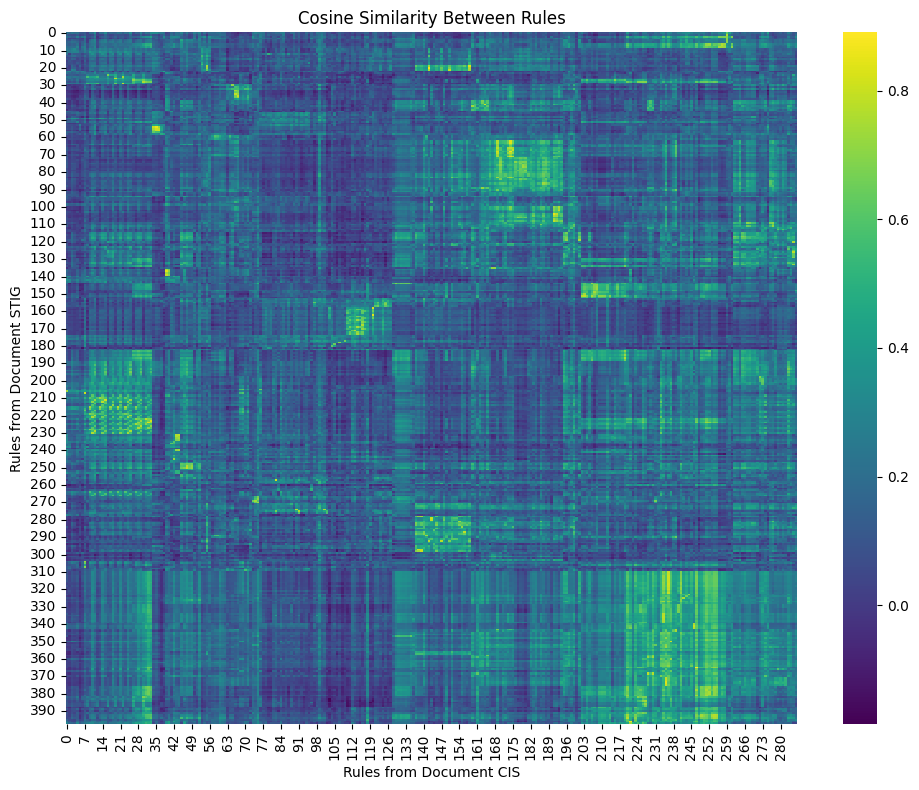

In [26]:
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(sim_matrix,
            cmap='viridis',
            annot=False,
            fmt=".2f")

plt.title("Cosine Similarity Between Rules")
plt.xlabel("Rules from Document CIS")
plt.ylabel("Rules from Document STIG")
plt.tight_layout()
plt.show()

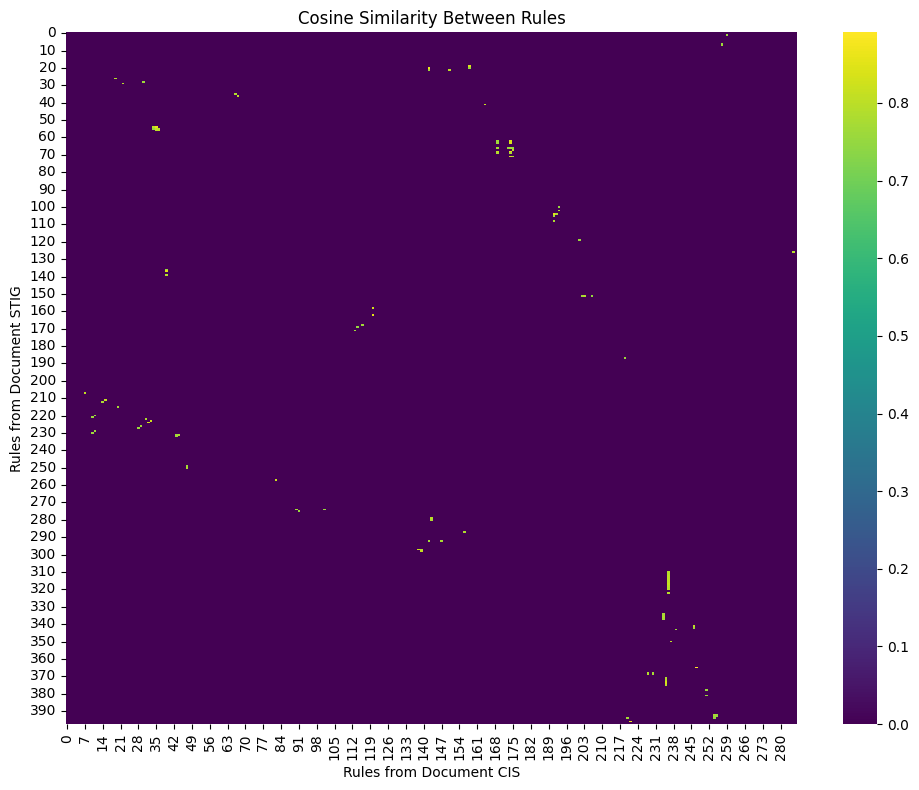

In [25]:
plt.figure(figsize=(10, 8))

threshold = 0.75
masked = sim_matrix.copy()
masked[masked < threshold] = 0
# Create heatmap
sns.heatmap(masked,
            cmap='viridis',
            annot=False,
            fmt=".2f")

plt.title("Cosine Similarity Between Rules")
plt.xlabel("Rules from Document CIS")
plt.ylabel("Rules from Document STIG")
plt.tight_layout()
plt.show()

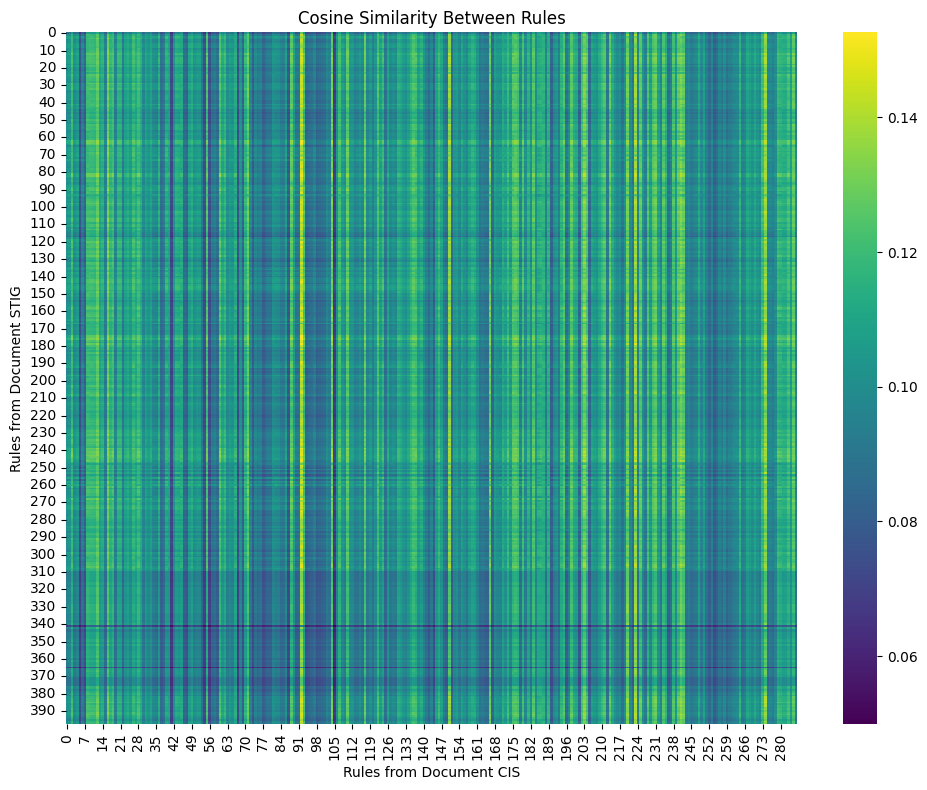

In [ ]:
dist = euclidean_distances(STIG_embeddings, CIS_embeddings)
inv_sim = 1 / (1 + dist)  # converts distance to similarity
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(inv_sim,
            cmap='viridis',
            annot=False,
            fmt=".2f")

plt.title("Cosine Similarity Between Rules")
plt.xlabel("Rules from Document CIS")
plt.ylabel("Rules from Document STIG")
plt.tight_layout()
plt.show()

# Find Match if Score Above Threshold

In [11]:
CIS_titles[285]

'6.2.10 Ensure local interactive user home directories are'

In [13]:
CIS_rules[285]

"6.2.10 Ensure local interactive user home directories are configured (Automated). The user home directory is space defined for the particular user to set local environment variables and to store personal files. While the system administrator can establish secure permissions for users' home directories, the users can easily override these. Users can be defined in /etc/passwd without a home directory or with a home directory that does not actually exist."

In [14]:
matches = []
threshold = 0.75
for i, cis_title in enumerate(CIS_titles):
    for j, stig_title in enumerate(STIG_titles):
        score = sim_matrix[j][i].item()
        if score >= threshold:
            matches.append({
                'cis_title': cis_title,
                'cis_index': i,
                'stig_title': stig_title,
                'stig_index': j,
                'score': score
            })
print(f"Match Length: {len(matches)}")
# Display matches
for match in matches:
    print(f"CIS - Index{match['cis_index']}: '{match['cis_title']}'")
    print(f"STIG - Index{match['stig_index']}: '{match['stig_title']}'")
    print(f"Score: {match['score']:.4f}")
    print("-" * 60)

Match Length: 125
CIS - Index7: '1.1.1.8 Ensure usb-storage kernel module is not available'
STIG - Index207: 'Disable Modprobe Loading of USB Storage Driver'
Score: 0.8076
------------------------------------------------------------
CIS - Index10: '1.1.2.1.3 Ensure nosuid option set on /tmp partition (Automated)'
STIG - Index221: 'Add nosuid Option to /tmp'
Score: 0.7591
------------------------------------------------------------
CIS - Index10: '1.1.2.1.3 Ensure nosuid option set on /tmp partition (Automated)'
STIG - Index230: 'Add nosuid Option to /var/tmp'
Score: 0.7610
------------------------------------------------------------
CIS - Index11: '1.1.2.1.4 Ensure noexec option set on /tmp partition (Automated)'
STIG - Index220: 'Add noexec Option to /tmp'
Score: 0.7545
------------------------------------------------------------
CIS - Index11: '1.1.2.1.4 Ensure noexec option set on /tmp partition (Automated)'
STIG - Index229: 'Add noexec Option to /var/tmp'
Score: 0.7593
------------

In [80]:
searched = semantic_search(STIG_embeddings, CIS_embeddings, top_k = 1)

In [84]:
matches = list(map(lambda x: x[0], searched))
# matches = [i for index, i in enumerate(matches) if i['score'] > 0.75]

In [87]:
len(matches)

398